## Stage 2b - adding problem

Stage 2 was getting too long!

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
DEVICE = torch.device("mps")
BATCH_SIZE = 64

In [3]:
class AddingDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, T: int = 50):
        self.epoch_size = epoch_size
        self.T = T
        
    def _generate_one(self):
        value = torch.randint(0, 2, size=(self.T,), dtype=torch.float32)
        marker = torch.zeros(self.T)
        marks = torch.randperm(self.T)[:2]
        marker[marks] = 1
        x = torch.vstack([value, marker]).T
        y = value[marks].sum()
        return x, y

    def __len__(self):
        return self.epoch_size
    
    def __getitem__(self, _):
        return self._generate_one()

In [4]:
class RNNModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=2,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)
    
class LSTMModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

In [5]:
def build_dataloaders(epoch_size: int = 10_000, T: int = 50) -> tuple[DataLoader, DataLoader]:
    """
    :return: dl_train, dl_test
    """
    ds_train = AddingDataset(epoch_size, T)
    ds_test = AddingDataset(epoch_size, T)
    dl_train = DataLoader(ds_train, BATCH_SIZE, shuffle=True)
    dl_test = DataLoader(ds_test, BATCH_SIZE, shuffle=False)
    return dl_train, dl_test


def evaluate(model: nn.Module, dl_test: DataLoader) -> float:
    model.eval()
    loss_fn = nn.MSELoss()
    total_loss = 0
    with torch.no_grad():
        for x, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            y_pred = model.forward(x)
            y_pred = y_pred[:, -1, :].squeeze() # only want final output
            
            loss = loss_fn(y_pred, y)
            
            total_loss += loss.item() * x.size(0)
    
    avg_loss = total_loss / len(dl_test.dataset)
    print(f'Test MSE: {avg_loss:.4f}')
    return avg_loss

def train(model: nn.Module, dl_train: DataLoader, n_epochs: int = 10, lr = 1e-3 * 16):
    loss_fn = nn.MSELoss()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    losses = []
    pbar = tqdm(range(n_epochs))
    for _ in pbar:
        total_loss = 0
        for x, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            optim.zero_grad()
            y_pred = model.forward(x)
            y_pred = y_pred[:, -1, :].squeeze() # only want final output

            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            total_loss += loss.detach().cpu() * x.size(0)
        
        avg_loss = total_loss / len(dl_train.dataset)
        pbar.set_postfix({"MSE": avg_loss})
        losses.append(avg_loss)
    plt.plot(losses)
    plt.show()
    
    

100%|██████████| 10/10 [00:14<00:00,  1.50s/it, MSE=tensor(0.4958)]


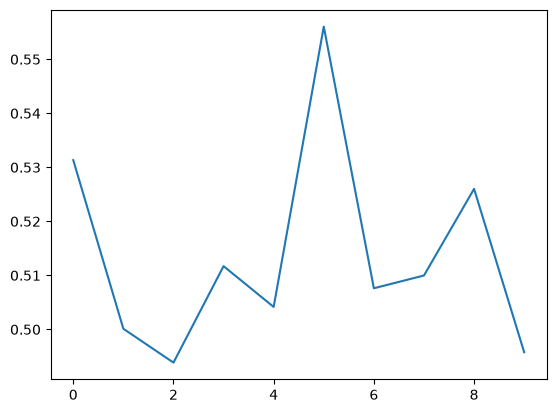

Test MSE: 0.4941


0.4940623252868652

In [6]:
# try rnn at T=50
dl_train, dl_test = build_dataloaders(T=50)
model = RNNModel().to(DEVICE)
train(model, dl_train, 10)
evaluate(model, dl_test)


100%|██████████| 10/10 [00:06<00:00,  1.51it/s, MSE=tensor(0.0003)]


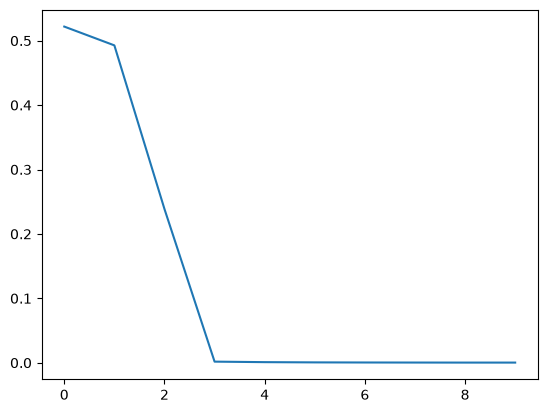

Test MSE: 0.0002


0.00016742266342043875

In [7]:
# try LSTM at T=50
dl_train, dl_test = build_dataloaders(T=50)
model = LSTMModel().to(DEVICE)
train(model, dl_train, 10)
evaluate(model, dl_test)

100%|██████████| 10/10 [00:09<00:00,  1.08it/s, MSE=tensor(0.0006)]


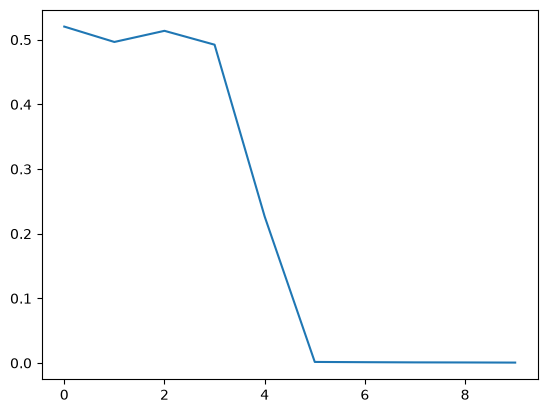

Test MSE: 0.0007


0.0007278772763907909

In [8]:
# 100?
dl_train, dl_test = build_dataloaders(T=100)
model = LSTMModel().to(DEVICE)
train(model, dl_train, 10)
evaluate(model, dl_test)

100%|██████████| 10/10 [00:13<00:00,  1.36s/it, MSE=tensor(0.0005)]


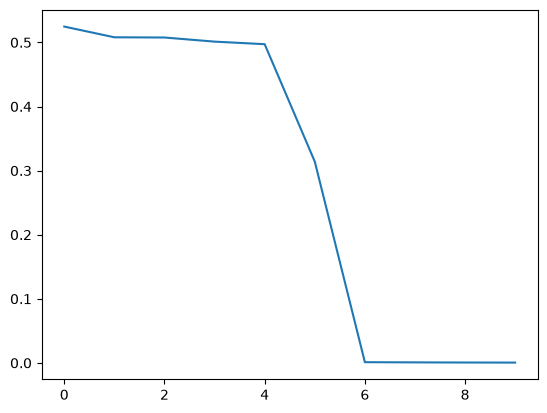

Test MSE: 0.0003


0.00034688547694240697

In [9]:
# 200?
dl_train, dl_test = build_dataloaders(T=200)
model = LSTMModel().to(DEVICE)
train(model, dl_train, 10)
evaluate(model, dl_test)

Results:

RNN remains stuck at initial performance of around 0.5 MSE. This is expected from always predicting 1:

`1/4 * (0 - 1)^2 + 1/2 * (1 - 1)^2 + 1/4 * (2 - 1)^2 = 0.5`

LSTM learns for T = 50, 100, 200 after 2, 4, 6 epochs respectively, getting test MSE ~= 0. Clear victory!

## Probing LSTM - what did it learn

$$
\begin{aligned}
i_t &= \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) &&\text{input gate}\\
f_t &= \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) &&\text{forget gate}\\
g_t &= \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) &&\text{candidate cell}\\
o_t &= \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) &&\text{output gate}\\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t\\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

In [10]:
fresh_model = LSTMModel()

In [11]:
# 1 - bias?

forget_bias = (model.lstm.bias_ih_l0 + model.lstm.bias_hh_l0).chunk(4)[1]
fresh_forget_bias = (fresh_model.lstm.bias_ih_l0 + fresh_model.lstm.bias_hh_l0).chunk(4)[1]
print(forget_bias.sum())
print(fresh_forget_bias.sum())

# We expect the learned bias to be large, implying not much forgetting happening

tensor(4.5236, device='mps:0', grad_fn=<SumBackward0>)
tensor(0.2357, grad_fn=<SumBackward0>)


tensor([-0.2760,  1.5149,  0.0370, -0.0255])

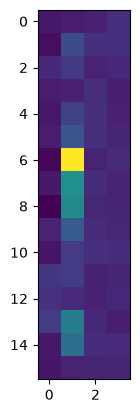

In [27]:
# 2,
# so we think input gate will focus on marker. That is the "gate" here
# candidate cell would be on the value
# look at weights to understand this

input_weight = model.lstm.weight_ih_l0[:16].detach().cpu()
fresh_input_weight = fresh_model.lstm.weight_ih_l0[:16].detach()

combined = torch.cat([input_weight, fresh_input_weight],dim=1)
plt.imshow(combined)
combined.mean(dim=0)

# We see the input hypothesis seems to hold. Dim 1 for learned LSTM has mean 1.5149, compared to ~=0 for fresh LSTM.

(tensor([-0.1042, -0.4423, -0.0477, -0.0339]),
 torch.return_types.max(
 values=tensor([1.0648, 1.1422, 0.2283, 0.2499]),
 indices=tensor([ 8,  7, 14, 13])))

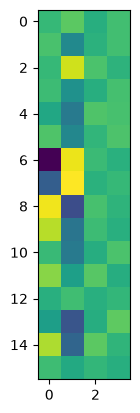

In [33]:
# 2, cand cell

cand_weight = model.lstm.weight_ih_l0[32:48].detach().cpu()
fresh_cand_weight = fresh_model.lstm.weight_ih_l0[32:48].detach()

combined = torch.cat([cand_weight, fresh_cand_weight],dim=1)
plt.imshow(combined)
combined.mean(dim=0), combined.max(dim=0) 

# > tensor([-0.1042, -0.4423, -0.0477, -0.0339])
# result here is less clear?

In [34]:
## 3 - gate activations over time

In [169]:
ds = AddingDataset()
x, y = ds._generate_one()
x = x.unsqueeze(0)  # add batch dim
x = x.to(DEVICE)

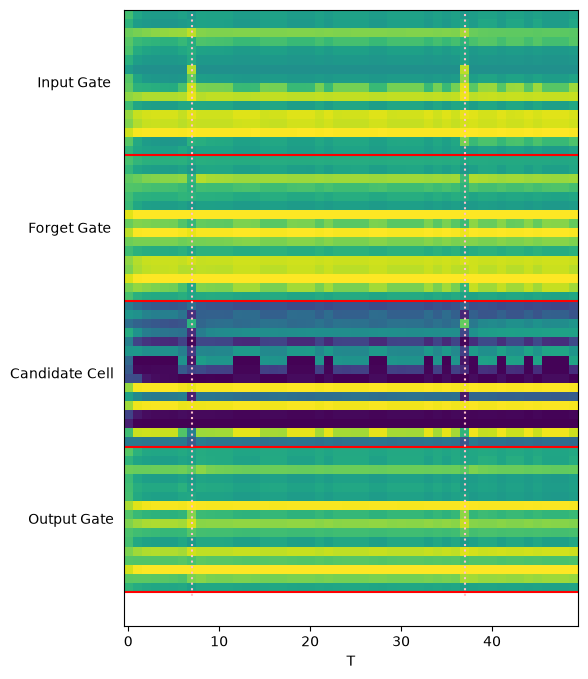

In [220]:
model.eval()

# with torch.no_grad():
# T = 50:
out_all = torch.zeros((51, 16)).to(DEVICE)
h_all = torch.zeros((51, 16)).to(DEVICE)
c_all = torch.zeros((51, 16)).to(DEVICE)

# Gather all hidden, cell states
h_n = torch.zeros((1, 1, 16), dtype=torch.float32).to(DEVICE)
c_n = torch.zeros((1, 1, 16), dtype=torch.float32).to(DEVICE)
for i in range(50):
    out, (h_n, c_n) = model.lstm(x[:, i, :].unsqueeze(1), (h_n, c_n))
    out_all[i + 1] = out.squeeze()
    h_all[i + 1] = h_n.squeeze()
    c_all[i + 1] = c_n.squeeze()

# Gate activations now!
# activations =
# (B, T, H)
activations = (
    x @ model.lstm.weight_ih_l0.T
    + h_all[:50] @ model.lstm.weight_hh_l0.T
    + model.lstm.bias_ih_l0
    + model.lstm.bias_hh_l0
)
activations[:, :, :32].sigmoid_()
activations[:, :, 32:48].tanh_()
activations[:, :, 48:].sigmoid_()

plt.figure().set_size_inches(12, 8)
plt.imshow(activations.detach().cpu().squeeze(0).T)
plt.xlabel("T")
plt.yticks([])
for i in range(4):
    plt.hlines((i + 1) * 16 + -0.5, -0.5, 50 - 0.5, colors='red')
marks = x[0, :, 1].nonzero().cpu().squeeze()
for mark in marks:
    plt.vlines(mark, 0, 64, colors='pink', linestyle='dotted')
plt.text(-10, 8, "Input Gate")
plt.text(-11, 24, "Forget Gate")
plt.text(-13, 40, "Candidate Cell")
plt.text(-11, 56, "Output Gate")
plt.show()

In [236]:
c_all.shape

torch.Size([51, 16])

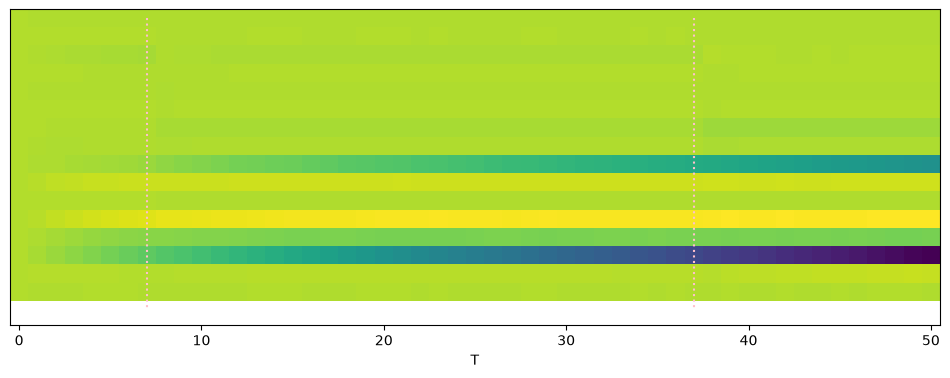

In [ ]:
# not much to see in c_all
# very subtle artifact after the marker
# looks like some units are just counters? they dominate the heatmap
plt.figure().set_size_inches(12, 8)
plt.imshow(c_all.detach().cpu().T)
plt.xlabel("T")
plt.yticks([])
marks = x[0, :, 1].nonzero().cpu().squeeze()
for mark in marks:
    plt.vlines(mark, 0, 16, colors='pink', linestyle='dotted')
plt.show()

In [171]:
# This is fantastic! we can clearly see distinct activations corresponding to the marks. Very clear one in the input gate!

## Ablation

In [ ]:
## What happens if we zero out specific weight where we saw the peaked activation in markers above?
# Let's try to be as surgical as possible

ablated_model = LSTMModel().to(DEVICE)
ablated_model.eval()
ablated_model.load_state_dict(model.state_dict())

with torch.no_grad():
    evaluate(ablated_model, dl_test) # quick check before, should be near perfect

    # Find the index which has the greatest abs change in activation for mark vs non mark
    # technically assumes marks aren't next to eachother, and not in idx 0
    ablation_index = (activations[0, marks, :16] - activations[0, marks - 1, :16]).sum(0).argmax()

    ablated_model.lstm.weight_ih_l0[ablation_index].zero_()
    # ablated_model.lstm.weight_hh_l0[ablation_index].zero_()

    evaluate(ablated_model, dl_test)

Test MSE: 0.0003
Test MSE: 0.5864


In [ ]:
## Alternatively, what if we just touch the FC layer weight?
# Looks like doesn't fully reset performance to ~0.5 MSE
# but rises to around 0.3

ablated_model = LSTMModel().to(DEVICE)
ablated_model.eval()
ablated_model.load_state_dict(model.state_dict())

with torch.no_grad():
    evaluate(ablated_model, dl_test) # quick check before, should be near perfect

    # Find the index which has the greatest abs change in activation for mark vs non mark
    # technically assumes marks aren't next to eachother, and not in idx 0
    ablation_index = (activations[0, marks, :16] - activations[0, marks - 1, :16]).sum(0).argmax()

    ablated_model.fc.weight[0, ablation_index].zero_()

    evaluate(ablated_model, dl_test)

Test MSE: 0.0004
Test MSE: 0.3115
